# Lab 8 Assignment — SVMs, Kernels, and the Margin

## 1. Setup

In [1]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs, load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid', context='notebook')
np.random.seed(42)
print('Setup complete.')

Setup complete.


## 2. Task A — Maximum Margin in Action

In [2]:
X_lin, y_lin = make_blobs(
    n_samples=180,
    centers=[(-2, -1), (2, 1)],
    cluster_std=0.9,
    random_state=42
)

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(
    X_lin, y_lin, test_size=0.25, stratify=y_lin, random_state=42)

print('Train:', Xa_tr.shape, ' Test:', Xa_te.shape)

Train: (135, 2)  Test: (45, 2)


In [3]:
def plot_svm_boundary(model, X, y, title='SVM decision boundary'):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                         np.linspace(y_min, y_max, 400))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=35, edgecolor='k', alpha=0.9)
    if hasattr(model, 'support_vectors_'):
        sv = model.support_vectors_
        plt.scatter(sv[:, 0], sv[:, 1], s=120, facecolors='none',
                    edgecolors='black', linewidths=1.6, label='Support Vectors')
        plt.legend()
    plt.title(title); plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

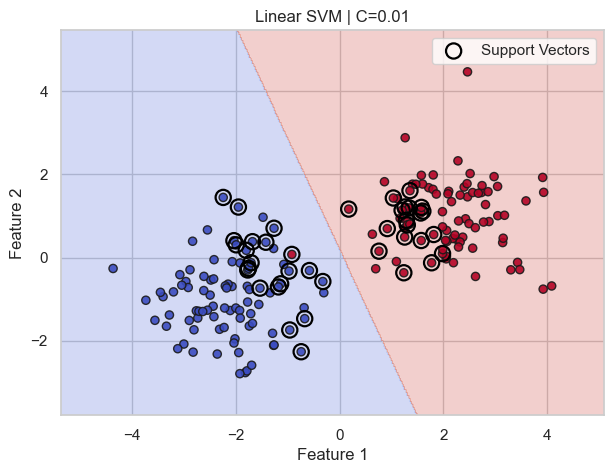

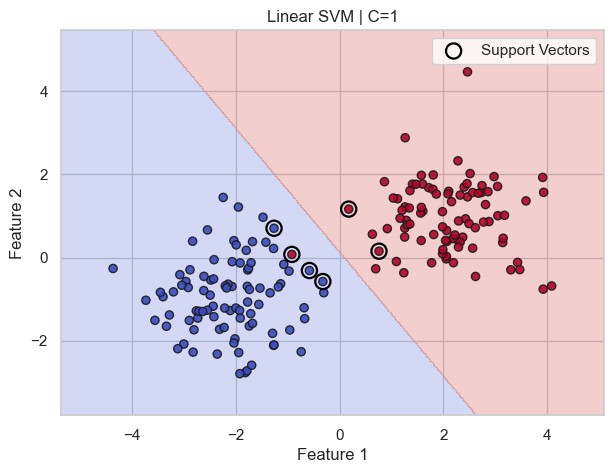

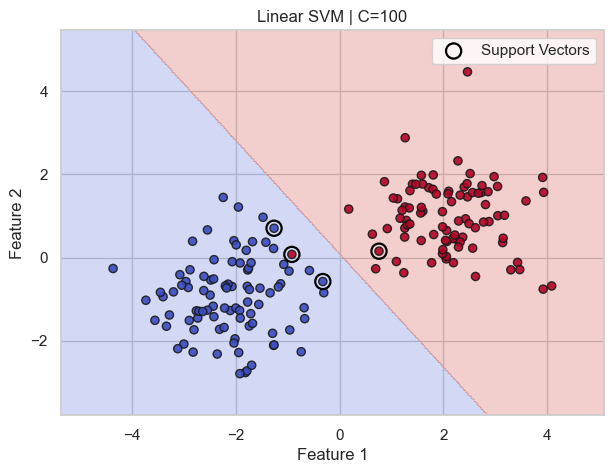

,C,margin_width,n_support_vectors,test_accuracy
0,0.01,3.6612,40,1.0
1,1.00,1.4505,6,1.0
2,100.00,1.3026,4,1.0


In [4]:
rows = []
for C in [0.01, 1, 100]:
    m = SVC(kernel='linear', C=C)
    m.fit(Xa_tr, ya_tr)
    margin = 2 / np.linalg.norm(m.coef_[0])
    n_sv = len(m.support_)
    acc = accuracy_score(ya_te, m.predict(Xa_te))
    rows.append([C, round(margin, 4), n_sv, round(acc, 4)])
    plot_svm_boundary(m, X_lin, y_lin, title=f'Linear SVM | C={C}')

task_a_table = pd.DataFrame(rows, columns=['C','margin_width','n_support_vectors','test_accuracy'])
task_a_table

## 3. Task B — Kernel Selection Report

### 3.1 Load data

In [5]:
df = None
try:
    import kagglehub
    path = kagglehub.dataset_download('uciml/breast-cancer-wisconsin-data')
    df = pd.read_csv(os.path.join(path, 'data.csv'))
    src = 'kaggle'
except Exception as e:
    print('Kaggle unavailable:', str(e)[:120])
    bc = load_breast_cancer(as_frame=True)
    df = bc.frame.copy()
    df['diagnosis'] = np.where(df['target'] == 1, 'B', 'M')
    df.drop(columns=['target'], inplace=True)
    src = 'sklearn_fallback'

for c in ['id', 'Unnamed: 32']:
    if c in df.columns:
        df.drop(columns=[c], inplace=True)

y = df['diagnosis'].map({'B': 0, 'M': 1}).astype(int)
X = df.drop(columns=['diagnosis'])

print('Source:', src, ' shape:', df.shape, ' features:', X.shape[1])
print('Class balance:'); print(y.value_counts(normalize=True).round(4).rename({0:'Benign',1:'Malignant'}))

Source: kaggle  shape: (569, 31)  features: 30
Class balance:
diagnosis
Benign       0.6274
Malignant    0.3726
Name: proportion, dtype: float64


### 3.2 Train/test split

In [6]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print('Train:', Xtr.shape, ' Test:', Xte.shape)

Train: (455, 30)  Test: (114, 30)


### 3.3 Grid search per kernel

In [7]:
grids = {
    'linear': {'svm__C': [0.01, 1, 100]},
    'rbf'   : {'svm__C': [0.1, 1, 10, 100],
               'svm__gamma': ['scale', 0.01, 0.1, 1]},
    'poly'  : {'svm__C': [0.1, 1, 10],
               'svm__degree': [2, 3, 4],
               'svm__gamma': ['scale', 0.01, 0.1]},
}

def tune(kernel, grid):
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('svm', SVC(kernel=kernel, random_state=42))])
    g = GridSearchCV(pipe, grid, scoring='f1', cv=5, n_jobs=-1)
    g.fit(Xtr, ytr)
    return g

best = {}
results = []
for k, g in grids.items():
    res = tune(k, g)
    best[k] = res

    pred = res.predict(Xte)

    t0 = time.perf_counter()
    for _ in range(50):
        res.predict(Xte)
    elapsed_ms = (time.perf_counter() - t0) / 50 * 1000

    results.append({
        'kernel': k,
        'best_params': {kk.replace('svm__',''): vv for kk, vv in res.best_params_.items()},
        'cv_f1': round(res.best_score_, 4),
        'test_f1': round(f1_score(yte, pred), 4),
        'recall_malignant': round(recall_score(yte, pred), 4),
        'test_acc': round(accuracy_score(yte, pred), 4),
        'inference_ms_full_test': round(elapsed_ms, 3),
        'per_sample_us': round(elapsed_ms * 1000 / len(Xte), 2),
    })

task_b_table = pd.DataFrame(results)
task_b_table

,kernel,best_params,cv_f1,test_f1,recall_malignant,test_acc,inference_ms_full_test,per_sample_us
0,linear,{'C': 0.01},0.9530,0.9367,0.8810,0.9561,1.001,8.78
1,rbf,"{'C': 10, 'gamma': 'scale'}",0.9647,0.9630,0.9286,0.9737,1.305,11.45
2,poly,"{'C': 1, 'degree': 3, 'gamma': 0.1}",0.9309,0.9091,0.8333,0.9386,1.150,10.09


### 3.4 Confusion matrices

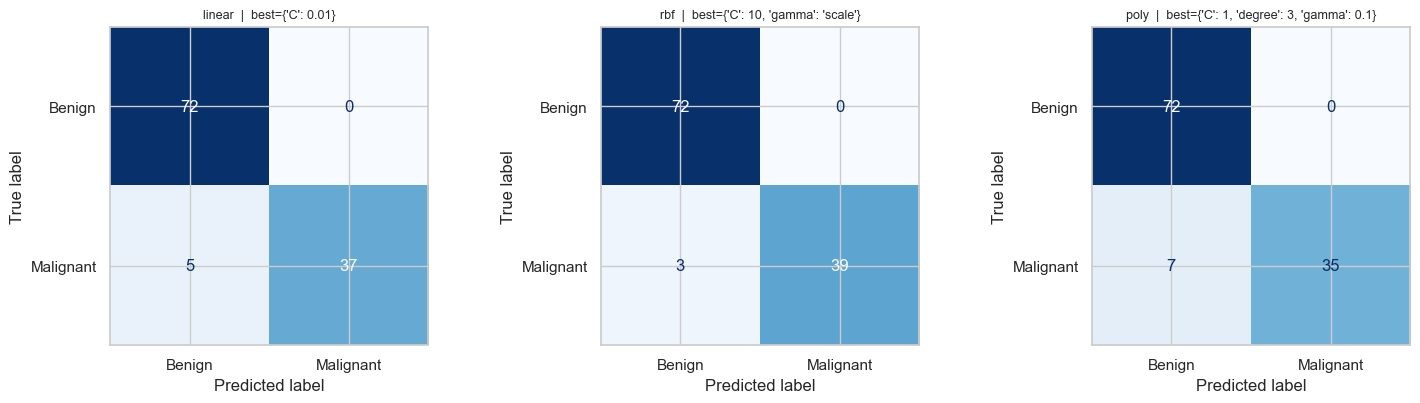

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (k, est) in zip(axes, best.items()):
    ConfusionMatrixDisplay.from_predictions(
        yte, est.predict(Xte),
        display_labels=['Benign', 'Malignant'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(f'{k}  |  best={ {kk.replace("svm__",""):vv for kk,vv in est.best_params_.items()} }', fontsize=9)
plt.tight_layout()
plt.show()

### 3.5 Classification reports

In [9]:
for k, est in best.items():
    print(f'==== {k.upper()} ===='); print('Best params:', est.best_params_)
    print(classification_report(yte, est.predict(Xte), target_names=['Benign','Malignant']))

==== LINEAR ====
Best params: {'svm__C': 0.01}
              precision    recall  f1-score   support

      Benign       0.94      1.00      0.97        72
   Malignant       1.00      0.88      0.94        42

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114

==== RBF ====
Best params: {'svm__C': 10, 'svm__gamma': 'scale'}
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114

==== POLY ====
Best params: {'svm__C': 1, 'svm__degree': 3, 'svm__gamma': 0.1}
              precision    recall  f1-score   support

      Benign       0.91      1.00      0.95        72
   Malignant       1.00      0.83      0.91   

## 4. Appendix

### 4.1 Confusion matrices (numeric)

In [10]:
for k, est in best.items():
    cm = confusion_matrix(yte, est.predict(Xte))
    print(f'\n[{k}]  best_params={est.best_params_}')
    print('            pred_B  pred_M')
    print(f'actual_B    {cm[0,0]:>6} {cm[0,1]:>6}')
    print(f'actual_M    {cm[1,0]:>6} {cm[1,1]:>6}')


[linear]  best_params={'svm__C': 0.01}
            pred_B  pred_M
actual_B        72      0
actual_M         5     37

[rbf]  best_params={'svm__C': 10, 'svm__gamma': 'scale'}
            pred_B  pred_M
actual_B        72      0
actual_M         3     39

[poly]  best_params={'svm__C': 1, 'svm__degree': 3, 'svm__gamma': 0.1}
            pred_B  pred_M
actual_B        72      0
actual_M         7     35


### 4.2 Task A summary table

In [11]:
task_a_table

,C,margin_width,n_support_vectors,test_accuracy
0,0.01,3.6612,40,1.0
1,1.00,1.4505,6,1.0
2,100.00,1.3026,4,1.0


### 4.3 Task B summary table

In [12]:
task_b_table

,kernel,best_params,cv_f1,test_f1,recall_malignant,test_acc,inference_ms_full_test,per_sample_us
0,linear,{'C': 0.01},0.9530,0.9367,0.8810,0.9561,1.012,8.88
1,rbf,"{'C': 10, 'gamma': 'scale'}",0.9647,0.9630,0.9286,0.9737,1.283,11.26
2,poly,"{'C': 1, 'degree': 3, 'gamma': 0.1}",0.9309,0.9091,0.8333,0.9386,1.396,12.24
